Importing Libraries


In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from collections import defaultdict
from stable_baselines3 import PPO


In [2]:
class HEMSTestEnv(gym.Env):
    def __init__(self):
        super(HEMSTestEnv, self).__init__()
        self.max_battery = 5.0
        self.battery_soc = 2.5

        # Efficiency
        self.charge_efficiency = 0.95
        self.discharge_efficiency = 0.90

        self.action_space = spaces.Discrete(4)  # Solar, Battery, UPS, Grid
        self.observation_space = spaces.Box(low=0, high=1, shape=(5,), dtype=np.float32)

        self.max_time = 24
        self.time_step = 0

    def _get_state(self):
        return np.array([
            self.time_step / 24,
            self.battery_soc / self.max_battery,
            self.solar_output / 5.0,
            self.load_demand / 5.0,
            1 if self.battery_soc > 3 else 0
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        self.battery_soc = 2.5
        self.time_step = 0
        self.solar_output = 0
        self.load_demand = 2
        return self._get_state(), {}

    def step(self, action):
        self.solar_output = max(0, 5 * np.sin(np.pi * self.time_step / 24))
        self.load_demand = 2 + np.random.rand()

        cost = 0

        # ✅ Solar priority + battery charging logic
        if action == 0:
            solar_used = min(self.solar_output, self.load_demand)
            leftover_solar = self.solar_output - solar_used
            battery_can_store = (self.max_battery - self.battery_soc) / self.charge_efficiency
            solar_to_battery = min(leftover_solar, battery_can_store)
            self.battery_soc += solar_to_battery * self.charge_efficiency
            cost = (self.load_demand - solar_used) * 0.3

        elif action == 1:
            deliverable = self.battery_soc * self.discharge_efficiency
            supplied = min(deliverable, self.load_demand)
            self.battery_soc -= supplied / self.discharge_efficiency
            cost = (self.load_demand - supplied) * 0.3

        elif action == 2:
            cost = 0 if self.battery_soc > 3 else self.load_demand * 0.5

        elif action == 3:
            cost = self.load_demand * 0.6

        reward = -cost
        self.time_step += 1
        done = self.time_step >= self.max_time
        return self._get_state(), reward, done, False, {}


PPO TRAINING MODEL


In [3]:
env = DummyVecEnv([lambda: HEMSTestEnv()])
model = PPO("MlpPolicy", env, verbose=0)

reward_log = []
print("✅ Training PPO...")
for i in range(20):
    model.learn(total_timesteps=5000, reset_num_timesteps=False)
    obs = env.reset()
    done = False
    total_reward = 0
    for _ in range(48):  # ✅ Simulate 24 hours
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = env.step(action)
        total_reward += reward[0]
    reward_log.append(total_reward)
    print(f"Episode {i+1}: Total Reward = {total_reward:.2f}")

✅ Training PPO...
Episode 1: Total Reward = -3.55
Episode 2: Total Reward = -3.59
Episode 3: Total Reward = -3.81
Episode 4: Total Reward = -3.40
Episode 5: Total Reward = -3.74
Episode 6: Total Reward = -2.50
Episode 7: Total Reward = -2.22
Episode 8: Total Reward = -2.37
Episode 9: Total Reward = -2.34
Episode 10: Total Reward = -2.03
Episode 11: Total Reward = -2.47
Episode 12: Total Reward = -3.01
Episode 13: Total Reward = -2.03
Episode 14: Total Reward = -2.29
Episode 15: Total Reward = -3.00
Episode 16: Total Reward = -2.58
Episode 17: Total Reward = -2.49
Episode 18: Total Reward = -2.34
Episode 19: Total Reward = -2.23
Episode 20: Total Reward = -2.55


Visualizing the PPO model


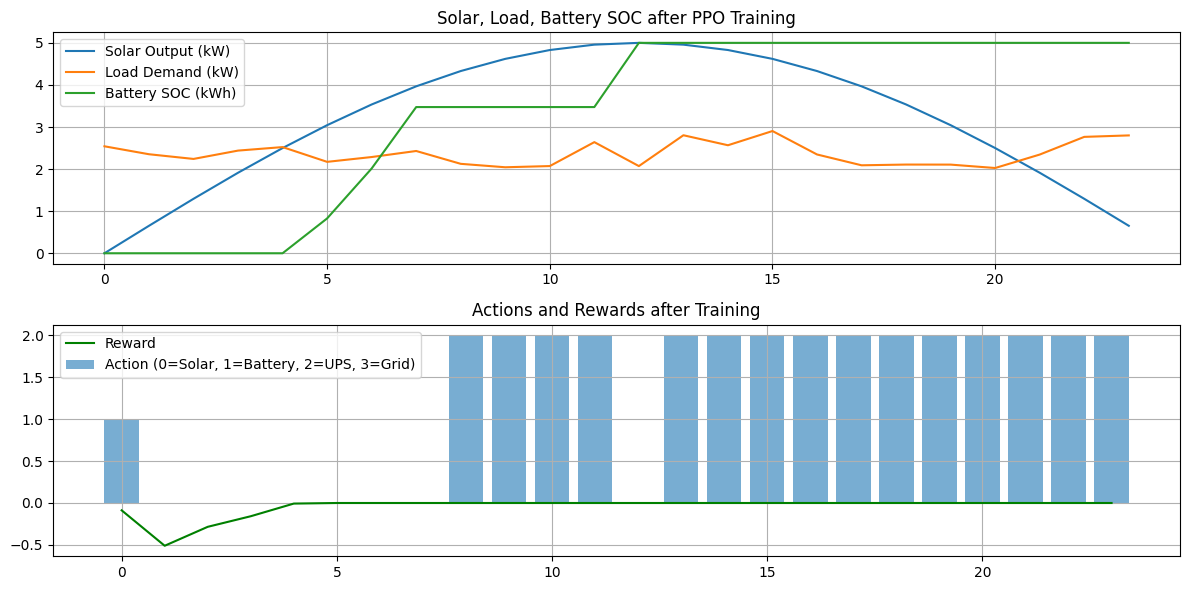

In [4]:
env_eval = HEMSTestEnv()
obs, _ = env_eval.reset()
done = False

time, solar_out, load_dem, battery_soc, actions, rewards = [], [], [], [], [], []

for t in range(24):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env_eval.step(action)
    time.append(t)
    solar_out.append(env_eval.solar_output)
    load_dem.append(env_eval.load_demand)
    battery_soc.append(env_eval.battery_soc)
    actions.append(action)
    rewards.append(reward)

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(time, solar_out, label='Solar Output (kW)')
plt.plot(time, load_dem, label='Load Demand (kW)')
plt.plot(time, battery_soc, label='Battery SOC (kWh)')
plt.title("Solar, Load, Battery SOC after PPO Training")
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.bar(time, actions, alpha=0.6, label='Action (0=Solar, 1=Battery, 2=UPS, 3=Grid)')
plt.plot(time, rewards, label='Reward', color='green')
plt.title("Actions and Rewards after Training")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


📊 PPO Agent Performance Summary
----------------------------------
Total Cost: $2.09
Solar    Used:  8 times | Energy: 13.96 kWh
Battery  Used:  1 times | Energy: 2.00 kWh
Ups      Used: 15 times | Energy: 36.65 kWh
Grid     Used:  0 times | Energy: 0.00 kWh


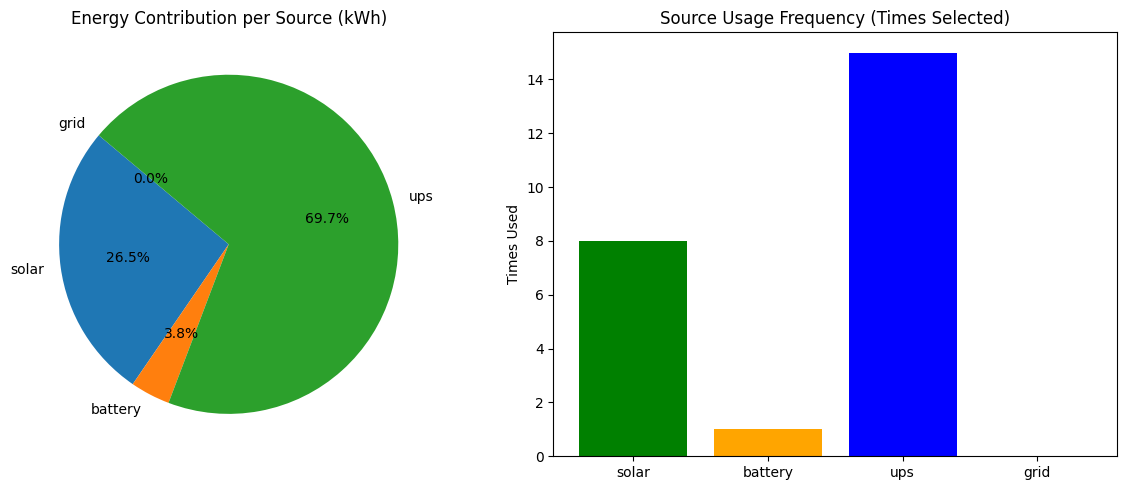

In [5]:


# ✅ 1️⃣ Load trained model and initialize environment
model = model
env = HEMSTestEnv()
state, _ = env.reset()

metrics = {
    "total_cost": 0.0,
    "source_use": defaultdict(int),
    "energy_from": defaultdict(float)
}

# ✅ 2️⃣ Simulation Loop (24 hours)
for t in range(24):
    action, _ = model.predict(state, deterministic=True)
    solar = env.solar_output
    demand = env.load_demand
    soc = env.battery_soc

    if action == 0:
        supplied = min(solar, demand)
        cost = (demand - supplied) * 0.3
        metrics["source_use"]["solar"] += 1
        metrics["energy_from"]["solar"] += supplied
    elif action == 1:
        deliverable = soc * env.discharge_efficiency
        supplied = min(deliverable, demand)
        cost = (demand - supplied) * 0.3
        metrics["source_use"]["battery"] += 1
        metrics["energy_from"]["battery"] += supplied
    elif action == 2:
        if soc > 3:
            supplied = demand
            cost = 0
        else:
            supplied = 0
            cost = demand * 0.5
        metrics["source_use"]["ups"] += 1
        metrics["energy_from"]["ups"] += supplied
    elif action == 3:
        supplied = demand
        cost = demand * 0.6
        metrics["source_use"]["grid"] += 1
        metrics["energy_from"]["grid"] += supplied

    metrics["total_cost"] += cost
    state, _, _, _, _ = env.step(action)

# ✅ 3️⃣ Summary Print
print("\n📊 PPO Agent Performance Summary")
print("----------------------------------")
print(f"Total Cost: ${metrics['total_cost']:.2f}")
for src in ["solar", "battery", "ups", "grid"]:
    print(f"{src.title():<8} Used: {metrics['source_use'][src]:2d} times | "
          f"Energy: {metrics['energy_from'][src]:.2f} kWh")

# ✅ 4️⃣ Visualization
sources = ["solar", "battery", "ups", "grid"]
energy = [metrics["energy_from"][src] for src in sources]
usage = [metrics["source_use"][src] for src in sources]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.pie(energy, labels=sources, autopct='%1.1f%%', startangle=140)
plt.title("Energy Contribution per Source (kWh)")

plt.subplot(1, 2, 2)
plt.bar(sources, usage, color=['green', 'orange', 'blue', 'red'])

plt.title("Source Usage Frequency (Times Selected)")
plt.ylabel("Times Used")

plt.tight_layout()
plt.show()


GA Optimization


In [8]:
import random
import numpy as np
from deap import base, creator, tools, algorithms

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

env = DummyVecEnv([lambda: HEMSTestEnv()])
  # Make sure this points to your environment code

# -- STEP 1: Define GA Fitness and Individual --
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

# Define hyperparameter search ranges:
HYPERS = {
    "learning_rate": (1e-5, 1e-3),
    "gamma": (0.9, 0.999),
    "gae_lambda": (0.8, 0.99),
    "ent_coef": (0.0, 0.05)
}

def create_individual():
    return [
        random.uniform(*HYPERS["learning_rate"]),
        random.uniform(*HYPERS["gamma"]),
        random.uniform(*HYPERS["gae_lambda"]),
        random.uniform(*HYPERS["ent_coef"])
    ]

# -- STEP 2: Evaluation Function --
def evaluate(individual):
    lr, gamma, gae_lambda, ent_coef = individual

    # Train agent briefly
    env = DummyVecEnv([lambda: HEMSTestEnv()])
    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=lr,
        gamma=gamma,
        gae_lambda=gae_lambda,
        ent_coef=ent_coef,
        verbose=0
    )
    model.learn(total_timesteps=20000)

    # Evaluate over 3 episodes
    rewards = []
    for _ in range(3):
        obs = env.reset()
        done = False
        total = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, info = env.step(action)
            total += reward[0] if isinstance(reward, (list, np.ndarray)) else reward
        rewards.append(total)
    avg_reward = np.mean(rewards)
    return (avg_reward,)

# -- STEP 3: GA Setup --
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=0.1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

# -- STEP 4: Run GA --
def run_ga(n_population=6, n_generations=5):
    pop = toolbox.population(n=n_population)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("max", np.max)
    stats.register("avg", np.mean)

    pop, log = algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.5, mutpb=0.2,
        ngen=n_generations,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    best = hof[0]
    print("\n🏆 Best hyperparameters found:")
    print(f"learning_rate: {best[0]:.6f}")
    print(f"gamma:         {best[1]:.4f}")
    print(f"gae_lambda:    {best[2]:.4f}")
    print(f"ent_coef:      {best[3]:.6f}")
    return log, best

if __name__ == "__main__":
    log, best = run_ga()


gen	nevals	max                	avg               
0  	6     	-1.2055820226669312	-1.654561161994934
1  	3     	-1.2055820226669312	-1.8453660011291504
2  	4     	-1.1103523969650269	-1.5485671758651733
3  	6     	-1.368882179260254 	-1.7383131980895996
4  	5     	-1.2440695762634277	-1.6663843393325806
5  	5     	-1.0032801628112793	-1.3911949396133423

🏆 Best hyperparameters found:
learning_rate: 0.000300
gamma:         0.9202
gae_lambda:    0.8270
ent_coef:      0.012785
